# Task 2 - Detection

## Import and setup

In [2]:
!pip install opencv-python numpy matplotlib open3d Pillow scipy sympy easydict torch pillow protobuf==3.20.0 shapely ipykernel ipywidgets open3d

In [3]:
import os

import cv2
from IPython.display import display
import numpy as np
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import open3d as o3d
from PIL import Image
from scipy.spatial.transform import Rotation
from sympy import Matrix
from easydict import EasyDict as edict
from typing import Tuple

import tools.dataset_tools as dataset_tools
from tools.frame_pb2 import Frame
import tools.plot_tools as plot_tools
import torch


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


## Process raw LiDAR point cloud data

In [4]:
frame = dataset_tools.read_frame("dataset/data_2/frame_0.pb")

# print number of lidars
print(f"Number of lidars: {len(frame.lidars)}")
lidar = frame.lidars[0]

# Extract pointcloud
pcl = dataset_tools.decode_lidar(lidar)
print(f"Pointcloud shape: {pcl.shape}")

Number of lidars: 1
Pointcloud shape: (196608, 4)


## Convert to Bird's Eye View representation

In [5]:
def visualize_bev(bev):
    """
    Visualize Bird's Eye View (BEV) data both as a combined map and individual channels
    
    Args:
        bev: numpy array of shape (channels, height, width)
    """
    # Create a figure with two rows
    plt.figure(figsize=(15, 10))
    
    # Plot combined BEV map
    plt.subplot(2, 1, 1)
    bev_map_display = np.transpose(bev, (1, 2, 0))
    plt.imshow(bev_map_display)
    plt.colorbar()
    plt.title("Combined Bird's Eye View Map")
    
    # Plot individual channels
    plt.subplot(2, 1, 2)
    titles = ['Height', 'Intensity', 'Density']
    for i, title in enumerate(titles):
        plt.subplot(2, 3, i + 4)  # Position in bottom row
        im = plt.imshow(bev_map_display[:,:,i])
        plt.title(title)
        plt.colorbar(im)
    
    # plt.tight_layout()
    plt.show()

In [6]:
config = edict()
config.lims = edict()
config.lims.x = [0, 50]
config.lims.y = [-25, 25]
config.lims.z = [-1, 3]
config.lims.intensity = [0, 1]
config.bev_height = 608
config.bev_width = 608

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..684.0].


BEV shape: (3, 608, 608)


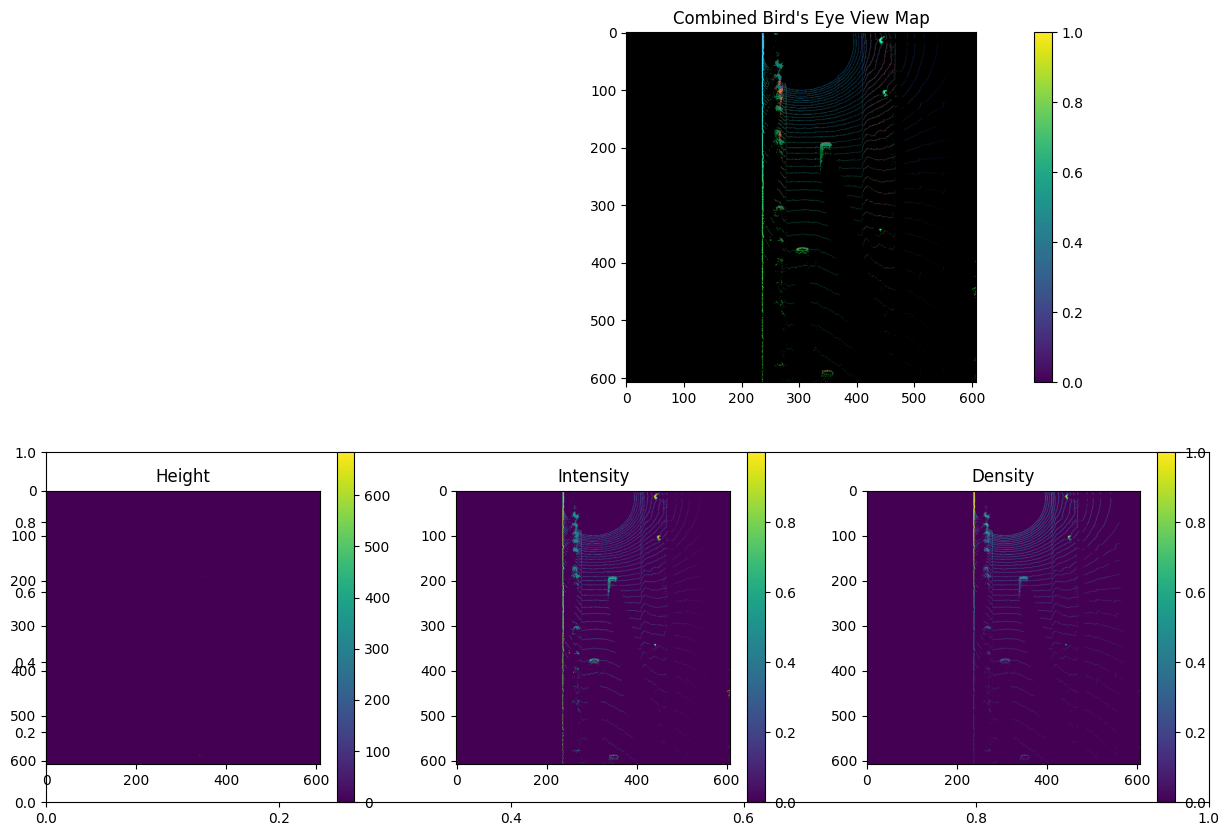

In [21]:
def pcl_to_bev(pcl: np.ndarray, configs: edict) -> np.ndarray:
    """SFA3D-style BEV map creation while maintaining compatibility with your config structure
    
    Args:
        pcl: pointcloud as numpy array [n_points, m_channels]
        configs: configuration parameters
    Returns:
        RGB_Map: BEV map as [3, height, width] array
    """
    # Create copy to avoid modifying original
    points = np.copy(pcl)
    
    # Filter points within detection range
    mask = np.where((points[:, 0] >= configs.lims.x[0]) & (points[:, 0] <= configs.lims.x[1]) &
                    (points[:, 1] >= configs.lims.y[0]) & (points[:, 1] <= configs.lims.y[1]) &
                    (points[:, 2] >= configs.lims.z[0]) & (points[:, 2] <= configs.lims.z[1]))
    points = points[mask]
    
    # Adjust height relative to ground (as in your implementation)
    points[:, 2] = points[:, 2] - configs.lims.z[0]
    
    height = configs.bev_height + 1
    width = configs.bev_width + 1
    
    # Calculate discretization (similar to your bev_x_discret and bev_y_discret)
    x_discretization = (configs.lims.x[1] - configs.lims.x[0]) / configs.bev_height
    y_discretization = (configs.lims.y[1] - configs.lims.y[0]) / configs.bev_width
    
    # Discretize Feature Map (SFA3D style)
    points[:, 0] = np.int_(np.floor(points[:, 0] / x_discretization))
    points[:, 1] = np.int_(np.floor(points[:, 1] / y_discretization) + width / 2)
    
    # Sort points (SFA3D style)
    sorted_indices = np.lexsort((-points[:, 2], points[:, 1], points[:, 0]))
    points = points[sorted_indices]
    _, unique_indices, unique_counts = np.unique(points[:, 0:2], axis=0, return_index=True, return_counts=True)
    points_top = points[unique_indices]
    
    # Initialize maps
    heightMap = np.zeros((height, width))
    intensityMap = np.zeros((height, width))
    densityMap = np.zeros((height, width))
    
    # Fill maps (SFA3D style)
    max_height = float(np.abs(configs.lims.z[1] - configs.lims.z[0]))
    heightMap[np.int_(points_top[:, 0]), np.int_(points_top[:, 1])] = points_top[:, 2] / max_height
    intensityMap[np.int_(points_top[:, 0]), np.int_(points_top[:, 1])] = points_top[:, 3]
    densityMap[np.int_(points_top[:, 0]), np.int_(points_top[:, 1])] = np.minimum(1.0, np.log(unique_counts + 1) / np.log(64))
    
    # Create RGB Map (same channel ordering as SFA3D)
    bev = np.zeros((3, height - 1, width - 1))
    bev[2, :, :] = densityMap[:configs.bev_height, :configs.bev_width]  # r_map
    bev[1, :, :] = heightMap[:configs.bev_height, :configs.bev_width]   # g_map
    bev[0, :, :] = intensityMap[:configs.bev_height, :configs.bev_width]# b_map
    
    return bev

# Test the function
bev = pcl_to_bev(pcl, config)
print(f"BEV shape: {bev.shape}")

# Visualize BEV channels
visualize_bev(bev)

## Feed into deep learning model to detect vehicles

## Evaluate detection performance